In [3]:
import nest_asyncio
nest_asyncio.apply()

import sys, os
sys.path.insert(0, r"C:\Users\chris\clee\ARBS")

import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import _usd_swaps_common as sdr
from SDRUtils.analytics.seasonality import get_fomc_dates

sdr.notebook_setup()

START = datetime.datetime(2026, 5, 18, tzinfo=datetime.timezone.utc)
END = datetime.datetime(2026, 5, 22, 23, 59, 59, tzinfo=datetime.timezone.utc)
CACHE_PATH = sdr.DEFAULT_CACHE_PATH

df = sdr.load_usd_swaps(START, END, cache_path=CACHE_PATH)
df = sdr.filter_new_risk(df)
print(f"Loaded {len(df):,} new-risk trades")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Classifying Trades: 100%|██████████| 5306/5306 [00:33<00:00, 156.85trade/s]
Failed to fetch pricer for 912810UV8 @ 2026-05-21 14:00:00-05:00: No snapshot within 0 days 00:30:00 of 3pm close
FETCHING INTRADAY DATA FROM BARCHART...: 100%|██████████| 7/7 [00:00<00:00, 10.03it/s]
Failed to fetch pricer for 912810UV8 @ 2026-05-21 14:00:00-05:00: No snapshot within 0 days 00:30:00 of 3pm close
Failed to fetch pricer for 91282CQQ7 @ 2026-05-21 14:00:00-05:00: "None of ['Timestamp'] are in the columns"
Failed to fetch pricer for 91282CQQ7 @ 2026-05-21 14:00:00-05:00: "None of ['Timestamp'] are in the columns"
Classifying Trades: 100%|██████████| 5191/5191 [00:34<00:00, 151.29trade/s]
Failed to fetch pricer for 912810UV8 @ 2026-05-20 14:00:00-05:00: No snapshot within 0 days 00:30:00 of 3pm close
Failed to fetch pricer for 91282CQQ7 @ 2026-05-20 14:00:00-05:00: "None of ['Timestamp'] are in the columns"
FETCHING INTRADAY DATA FROM BARCHART...: 100%|██████████| 6/6 [00:00<00:00, 12.64it/s]
Faile

Loaded 0 new-risk trades


## 1. SOFR vs FedFunds OIS Volume Split
Daily DV01 by rate index. Track percentage of total in each category.
53% volume growth in SOFR-FF basis swaps to $14.4T in 2025.

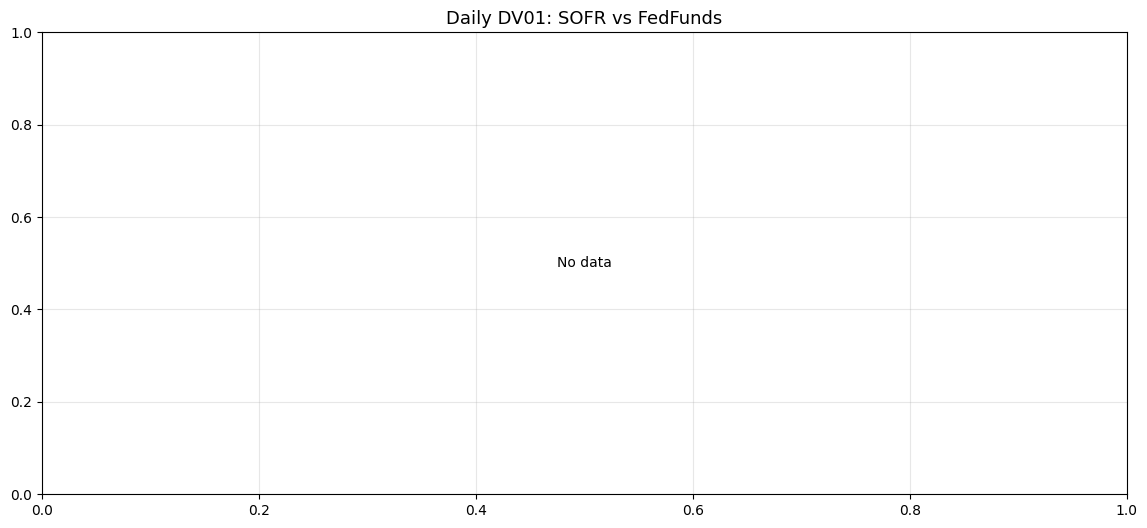

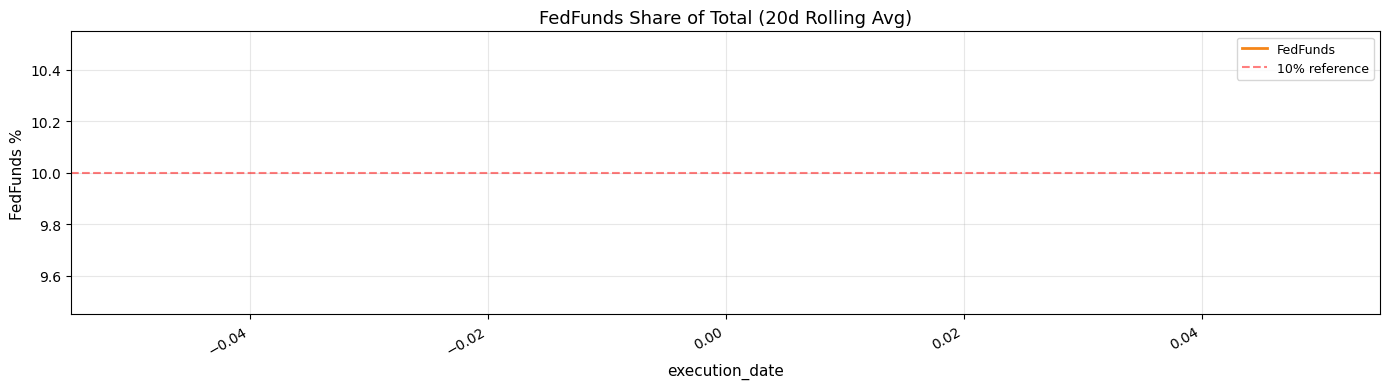

SOFR DV01: $0 (0.0%)
FedFunds DV01: $0 (0.0%)


In [4]:
sofr = sdr.filter_by_rate_index(df, "SOFR")
sofr_compound = sdr.filter_by_rate_index(df, "SOFR_COMPOUND")
ff = sdr.filter_by_rate_index(df, "FED_FUNDS")
ff_compound = sdr.filter_by_rate_index(df, "FED_FUNDS_COMPOUND")

sofr_all = pd.concat([sofr, sofr_compound])
ff_all = pd.concat([ff, ff_compound])

sofr_daily = sofr_all.groupby("execution_date")["dv01"].sum()
ff_daily = ff_all.groupby("execution_date")["dv01"].sum()

split = pd.DataFrame({"SOFR": sofr_daily, "FedFunds": ff_daily}).fillna(0).sort_index()
split.index = pd.to_datetime(split.index)

sdr.plot_stacked_area(split, "Daily DV01: SOFR vs FedFunds", color_map=sdr.RATE_INDEX_COLORS)
plt.show()

# Percentage split
split_pct = split.div(split.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(14, 4))
split_pct["FedFunds"].rolling(20, min_periods=3).mean().plot(ax=ax, color="#F58518", linewidth=2)
ax.set_title("FedFunds Share of Total (20d Rolling Avg)")
ax.set_ylabel("FedFunds %")
ax.axhline(10, color="red", linestyle="--", alpha=0.5, label="10% reference")
ax.legend()
plt.tight_layout()
plt.show()

_total_idx = sofr_all['dv01'].sum() + ff_all['dv01'].sum()
_sofr_pct = sofr_all['dv01'].sum() / _total_idx * 100 if _total_idx > 0 else 0
_ff_pct = ff_all['dv01'].sum() / _total_idx * 100 if _total_idx > 0 else 0
print(f"SOFR DV01: {sdr.format_dv01(sofr_all['dv01'].sum())} ({_sofr_pct:.1f}%)")
print(f"FedFunds DV01: {sdr.format_dv01(ff_all['dv01'].sum())} ({_ff_pct:.1f}%)")

## 2. Basis Swap Volumes
Filter to SOFR-FF basis swaps. DV01 by tenor.

In [5]:
basis = sdr.filter_by_basis_type(df, "SOFR_FF")
if not basis.empty:
    basis_daily = basis.groupby("execution_date")["dv01"].sum()
    basis_daily.index = pd.to_datetime(basis_daily.index)
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(basis_daily.index, basis_daily.values, alpha=0.6, color="#E45756")
    ma = basis_daily.rolling(20, min_periods=3).mean()
    ax.plot(ma.index, ma.values, color="black", linewidth=2, label="20d MA")
    ax.set_title("SOFR-FedFunds Basis Swap Daily DV01")
    ax.set_ylabel("DV01 ($)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No SOFR_FF basis swaps found. Check if basis_type column is populated.")

No SOFR_FF basis swaps found. Check if basis_type column is populated.


## 3. Basis Activity Heatmap
DV01 by tenor x month. Shows where on the curve basis is being traded.

In [6]:
if not basis.empty and "tenor_label" in basis.columns:
    basis_monthly = basis.copy()
    basis_monthly["month"] = pd.to_datetime(basis_monthly["execution_date"]).dt.to_period("M").astype(str)
    
    hm = basis_monthly.pivot_table(
        index="tenor_label", columns="month", values="dv01", aggfunc="sum", fill_value=0,
    )
    hm = hm.reindex([t for t in sdr.TENOR_ORDER if t in hm.index])
    
    sdr.plot_heatmap(hm / 1e6, "SOFR-FF Basis DV01 by Tenor x Month ($M)", cmap="YlOrRd", fmt=".1f")
    plt.show()

## 4. Regime Detection
Rolling FF/total ratio. Highlight spikes (e.g., Q3 2024: 7%→24%).

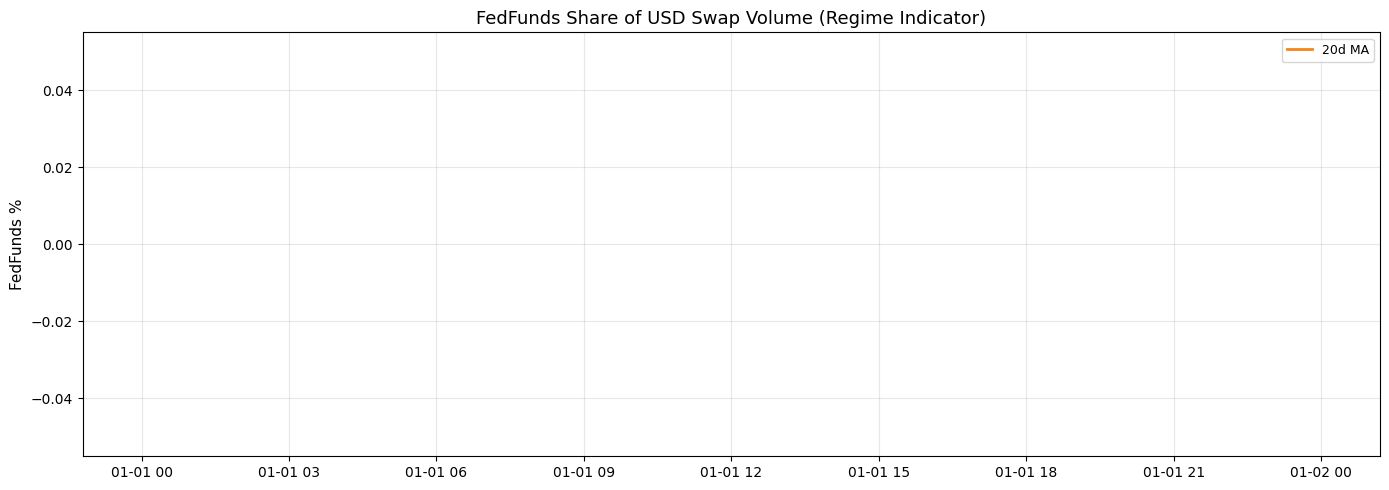

In [7]:
ff_ratio = (ff_daily / (sofr_daily + ff_daily).clip(lower=1) * 100).fillna(0)
ff_ratio.index = pd.to_datetime(ff_ratio.index)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(ff_ratio.index, ff_ratio.values, alpha=0.3, color="#F58518")
ma = ff_ratio.rolling(20, min_periods=3).mean()
ax.plot(ma.index, ma.values, color="#F58518", linewidth=2, label="20d MA")
ax.set_title("FedFunds Share of USD Swap Volume (Regime Indicator)")
ax.set_ylabel("FedFunds %")
ax.legend()
plt.tight_layout()
plt.show()

# Detect regime shifts (large month-over-month changes)
monthly_ratio = ff_ratio.resample("ME").mean()
mom_change = monthly_ratio.diff()
big_shifts = mom_change[mom_change.abs() > 3]
if not big_shifts.empty:
    print("Significant regime shifts (>3pp monthly change):")
    for date, change in big_shifts.items():
        print(f"  {date.date()}: {change:+.1f}pp (from {monthly_ratio.get(date - pd.offsets.MonthEnd(1), np.nan):.1f}% to {monthly_ratio.get(date, np.nan):.1f}%)")

## 5. FOMC Overlay
Basis volumes and FF share around FOMC meeting dates.

In [8]:
fomc_dates = get_fomc_dates()
fomc_in_range = [d for d in fomc_dates if START.date() <= d <= END.date()]

if fomc_in_range:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(ff_ratio.index, ff_ratio.values, color="#F58518", alpha=0.5, linewidth=0.8)
    ma_plot = ff_ratio.rolling(20, min_periods=3).mean()
    ax.plot(ma_plot.index, ma_plot.values, color="#F58518", linewidth=2)
    
    for fd in fomc_in_range:
        ax.axvline(pd.Timestamp(fd), color="red", linestyle="--", alpha=0.3, linewidth=0.8)
    
    ax.set_title("FedFunds Share with FOMC Meeting Dates")
    ax.set_ylabel("FedFunds %")
    plt.tight_layout()
    plt.show()